RQ7 – Predicting profit using machine learning

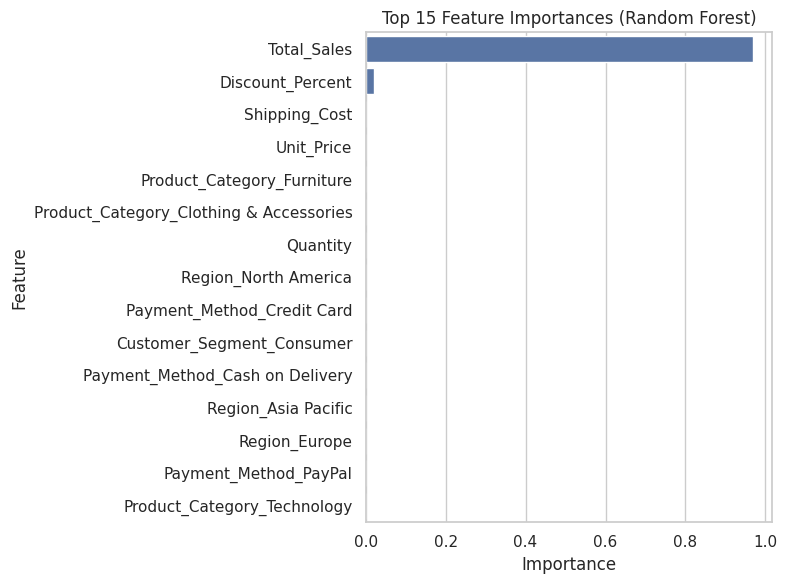

In [16]:
# RQ7: Predicting profit using machine learning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

DATA_PATH = Path("/kaggle/input/datasets/bibirehana/global-e-commarce-sales-data-analysis/global_ecommerce_sales.csv")
df = pd.read_csv(DATA_PATH)

OUTPUT_DIR = Path("./rq7_outputs")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

# -------------------
# 1. Feature selection
# -------------------
numeric_features = ['Quantity', 'Unit_Price', 'Discount_Percent', 'Shipping_Cost', 'Total_Sales']
categorical_features = ['Region', 'Product_Category', 'Customer_Segment', 'Payment_Method']

# Drop rows with missing target
df = df.dropna(subset=['Profit'])

X = df[numeric_features + categorical_features]
y = df['Profit']

# -------------------
# 2. Preprocessing
# -------------------
numeric_transformer = 'passthrough'
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# -------------------
# 3. Train/test split
# -------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------
# 4. Models
# -------------------
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

results = []

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)
results_df.to_csv(OUTPUT_DIR / "RQ7_Table_Model_Performance.csv", index=False)

# -------------------
# 5. Feature importance from RandomForest
# -------------------
# Refit RF pipeline to full data for importance
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_pipe = Pipeline(steps=[('preprocessor', preprocessor),
                         ('model', rf)])
rf_pipe.fit(X, y)

# Get feature names after one-hot encoding
ohe = rf_pipe.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(categorical_features)
feature_names = numeric_features + list(cat_feature_names)

importances = rf_pipe.named_steps['model'].feature_importances_
feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feat_imp.to_csv(OUTPUT_DIR / "RQ7_Table_Feature_Importance.csv", index=False)

# -------------------
# 6. Plot feature importance
# -------------------
sns.set(style="whitegrid")

top_n = 15
top_feat = feat_imp.head(top_n)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=top_feat,
    x='Importance',
    y='Feature'
)
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "RQ7_Figure1_Feature_Importance.pdf", format="pdf")
plt.show()
plt.close()



### Interpretation of chart.

- Total Sales is the strongest predictor of Profit, which is expected because profit is mathematically tied to revenue.

- Discount Percent is highly influential, showing that discounting directly affects profit margins and overall profitability.

- Shipping Cost also plays a major role, indicating that logistics expenses significantly impact final profit outcomes.

- Unit Price contributes meaningfully, reflecting how higher‑priced items tend to generate higher absolute profit values.

- Furniture and Clothing & Accessories categories show strong importance, suggesting that product category strongly influences profit variability.

- Quantity ordered has moderate importance, meaning order size affects profit but less than pricing‑related variables.

- Regional variables (North America, Asia Pacific, Europe) appear in the mid‑to‑lower range, showing geography matters but is not the primary driver.

- Payment method features (Credit Card, Cash on Delivery, PayPal) have lower importance, indicating payment choice has limited effect on profit.

- Customer Segment (Consumer) shows relatively low importance, suggesting segment differences do not strongly influence profit prediction.

- Technology category has the lowest importance among top features, implying its profit patterns are more stable or less variable.

In [17]:
df_performance = pd.read_csv("/kaggle/working/rq7_outputs/RQ7_Table_Model_Performance.csv")
print(df_performance)

              Model        MAE        RMSE        R2
0  LinearRegression  12.327003  787.286064  0.952705
1      RandomForest   7.094106  678.136891  0.959262


- Random Forest outperforms Linear Regression, achieving lower MAE and RMSE and a slightly higher R².

- Both models achieve very high R² values (≈0.95–0.96), indicating that the selected features explain most of the variation in profit.

- Random Forest’s lower MAE (7.09 vs 12.33) shows it makes smaller average prediction errors.

- Random Forest’s RMSE is also lower (678 vs 787), meaning it handles large errors better than Linear Regression.

- Linear Regression still performs strongly, suggesting the relationship between predictors and profit is mostly linear.

- The improvement from Random Forest indicates non‑linear patterns exist, which tree‑based models capture more effectively.

- Overall, Random Forest is the better predictive model, but both models are reliable for profit estimation.